## AISE4010- Assignment2 - Time Series Forecasting using CNN, RNN, LSTM and GRU

## Grade: 100 points

### Instructions

#### Follow These Steps before submitting your assignment 

1. Complete the notebook.

2. Make sure all plots have axis labels.

3. Once the notebook is complete, `Restart` your kernel by clicking 'Kernel' > 'Restart & Run All'.

4. Fix any errors until your notebook runs without any problems.

5. Submit one completed notebook for the group to OWL by the deadline.

6. Make sure to reference all external code and documentation used.

### Dataset

The `StockData.csv` represents a time series dataset designed to simulate the behavior of stock prices over a period of 1000 days, starting from January 1, 2023. This dataset includes key features commonly found in stock market data, such as opening prices, closing prices, daily highs, daily lows, and trading volume. 

Features:
- Date: The timestamp representing the specific day for each record.
- Open: The stock's price at the start of the trading day. 
- High: The highest price of the stock during the trading day. It is generally higher than the opening price, reflecting intraday market movements.
- Low: The lowest price of the stock during the trading day. It is usually lower than the opening price, capturing downward movements in the market.
- Close: The stock’s price at the end of the trading day. This price reflects the market's closing valuation and fluctuates within a range close to the opening price.
- Volume: The number of shares traded during the day.

### Question 1 - Data Preprocessing (15%)
- Q1.1 Load the provided dataset and plot the `Closing prices` time series. (5%)
- Q1.2 (5%): 

  - a) Decompose the time series into its components and explain them.  
  - b) What do the trend and seasonality components tell you about the overall behavior of the time series? How does understanding     these components help in selecting a model for time series forecasting?
- Q1.3 Restructure the time series using a sliding window approach (with size 10) to prepare it for supervised learning. Split the `Closing prices` time series into 80% for training and 20% for testing. (5%)


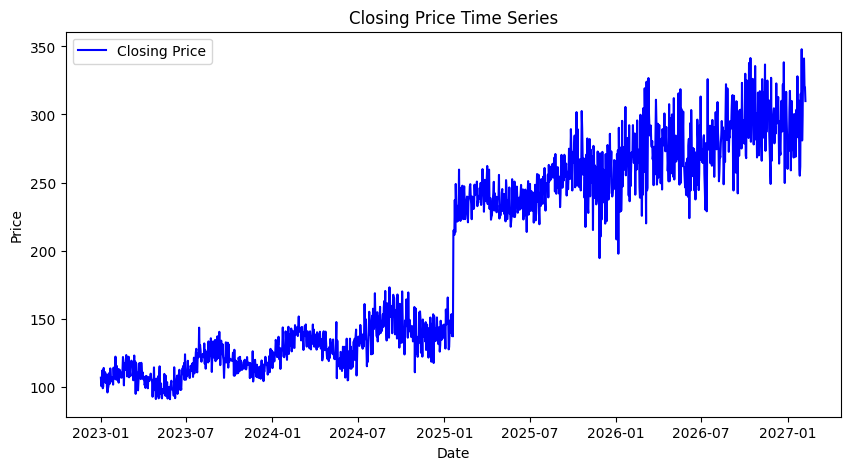

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import numpy as np

# Load dataset
data = pd.read_csv("StockData.csv")

# Ensure Date column is in datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Sort by date (in case it’s not sorted)
data = data.sort_values('Date')

# Set Date as index
data.set_index('Date', inplace=True)

# Plot Closing Prices
plt.figure(figsize=(10, 5))
plt.plot(data['Close'], label='Closing Price', color='blue')
plt.title('Closing Price Time Series')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

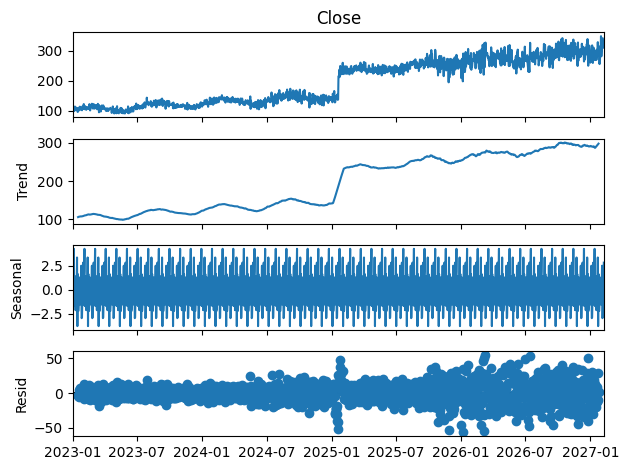

In [8]:
# Q1.2 Time Series Decomposition

# Perform additive decomposition (can use multiplicative if data shows proportional seasonality)
decomposition = seasonal_decompose(data['Close'], model='additive', period=30)
# (USING A 30 DAY (monthly() PERIOD AS OUR CYCLE) 
# Plot components
decomposition.plot()
plt.show()

*Write your Answer to Q1.2-b here:*

Trend:

The trend represents the longterm movement or outlook of the data. It shows weather the stock is generally increasing or decreasing. The function applies a moving average to smooth out short term fluctuations. In our case we see a general gradual increase with a significant 'bump' around January 2025 

Seasonality : 

From the graph we can see that there is a repeating pattern during our 30 day window. The Amplitude shows us the variation on how much the price tends to go up and down. The frequent oscillations goes to shows how often short term oscillations occur, showing short term volatility.

Understanding the trend and seasonality in a time series helps determine which forecasting model to use. If a strong trend exists, the data is non-stationary, so models like ARIMA (with differencing) are suitable to capture long-term direction. If seasonality is present, models such as SARIMA are preferred since they explicitly handle repeating patterns. When both trend and seasonality appear, these combined models perform best. In short, decomposition reveals the structure of the data so you can choose a model that accurately captures its underlying behavior.

In [9]:
from sklearn.model_selection import train_test_split

# Load the dataset
data = pd.read_csv('StockData.csv', parse_dates=['Date'], index_col='Date')

# Extract the closing price
close_prices = data['Close'].values

# Sliding window size
window_size = 10

# Create input (X) and output (y) pairs
X, y = [], []
for i in range(len(close_prices) - window_size):
    X.append(close_prices[i:i + window_size])   # previous 10 days
    y.append(close_prices[i + window_size])     # next day (target)

X = np.array(X)
y = np.array(y)

# Split into training (80%) and testing (20%)
split_index = int(len(X) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


X_train shape: (1192, 10)
y_train shape: (1192,)
X_test shape: (298, 10)
y_test shape: (298,)


### Question2 - 1D Convolutional Neural Network (CNN) (20%)
- Q2.1 Create a 1D CNN model for time series forecasting. The model should have two convolutional layers of size 64 and 32 and kernel size of 3, fully connected layer of size 50, droup out of 0.3, and ReLU activation. Train the model using the provided dataset for 50 epochs. Use the batch_size of 32, and ADAM optimizer. Plot the training loss and validation loss. (12%)
- Q2.2 Evaluate the model's performance using RMSE and MAE on the test set. Plot the predicted values alongside the actual values to visualize how well the model is forecasting the time series. (6%)
- Q2.3 How does the 1D-CNN perform in terms of capturing short-term dependencies? Based on the RMSE and MAE values, do you think this model can effectively capture long-term trends? Why or why not? (2%)


Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 12872.1455 - val_loss: 536.1013
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1411.1210 - val_loss: 681.9890
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1136.5262 - val_loss: 695.6575
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1140.8097 - val_loss: 685.6196
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1141.3726 - val_loss: 495.8456
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1004.9181 - val_loss: 504.6999
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 832.3187 - val_loss: 499.1130
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 976.6694 - val_loss: 744.1128
Epoch 9/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 867.2081 - val_loss: 536.3391
Epoch 10/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 964.3088 - val_loss: 532.3130
Epoch 11/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 895.8259 - val_loss: 497.1448
Epoch 12/50
38/38 ━━━━━

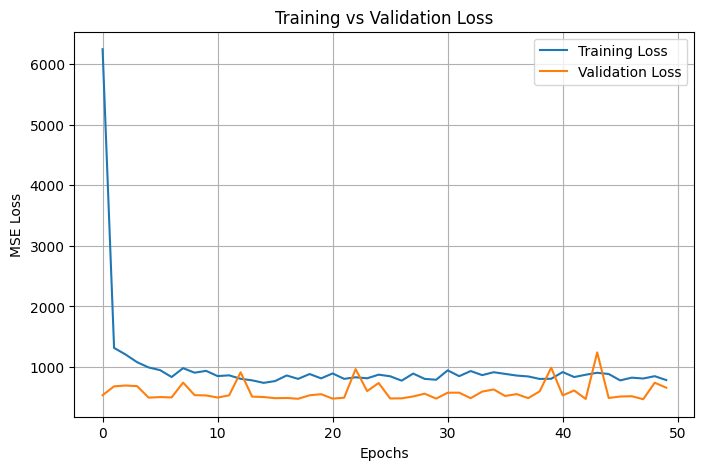

In [13]:
#Q2.1

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

# Assuming you already have X_train, X_test, y_train, y_test from Q1.3

# Reshape input to 3D (samples, timesteps, features)
# Here each window is treated as a sequence of 10 timesteps with 1 feature
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Build the 1D CNN model
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)),
    Conv1D(filters=32, kernel_size=3, activation='relu'),
    Flatten(),
    Dense(50, activation='relu'),
    Dropout(0.3),
    Dense(1)  # Output layer for next-day prediction
])

# Compile model
model.compile(optimizer=Adam(), loss='mse')

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# Plot training vs validation loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Root Mean Squared Error (RMSE): 25.6846
Mean Absolute Error (MAE): 20.5021


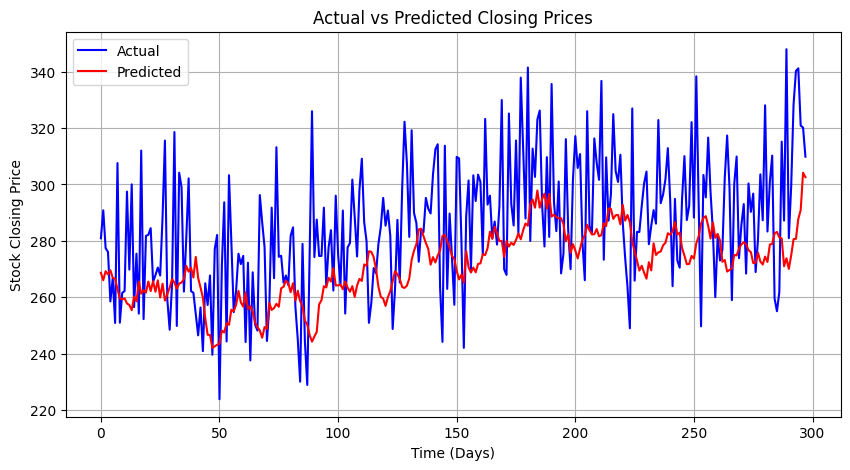

In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate RMSE and MAE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("Root Mean Squared Error (RMSE):", round(rmse, 4))
print("Mean Absolute Error (MAE):", round(mae, 4))

# Plot actual vs predicted values
plt.figure(figsize=(10,5))
plt.plot(y_test, label='Actual', color='blue')
plt.plot(y_pred, label='Predicted', color='red')
plt.title('Actual vs Predicted Closing Prices')
plt.xlabel('Time (Days)')
plt.ylabel('Stock Closing Price')
plt.legend()
plt.grid(True)
plt.show()


*Write your Answer to Q2.3 Here:*

The 1D-CNN model performs moderately well in capturing short-term dependencies, but its predictions show limited ability to capture short term volatility in stock prices. As seen in the plot, the model consistently underestimates actual prices and struggles with short-term volatility. The relatively high RMSE (25.68) and MAE (20.50) indicate noticeable prediction errors. 

However, the model does capture the broader long-term trend over 30-day periods, suggesting that while it recognizes general directional movement, it lacks the sensitivity to  track day-to-day variation. This is expected since CNNs primarily learn local patterns within the sliding window and are less effective for modeling long-range temporal dependencies.

### Question 3 - Recurrent Neural Networks (RNN) (20%)
- Q3.1 Create an RNN model for time series forecasting. The model should include a SimpleRNN layer of size 40 and ReLU activation. Train the model using the provided dataset for 50 epochs. Use the batch_size of 16, and ADAM optimizer. Plot the training loss and validation loss. (12%)
- Q3.2 Evaluate the model's performance using RMSE and MAE on the test set. Plot the predicted values alongside the actual values to visualize how well the model is forecasting the time series. (6%)
- Q3.3 Why did we use a smaller batch size compared to CNN model. Why might RNN struggle with long-term dependencies, and how is this reflected in the evaluation metrics? (2%)


Epoch 1/50


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2390.7341 - val_loss: 571.5746
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 172.3545 - val_loss: 514.0394
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 156.7812 - val_loss: 546.3403
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 178.4954 - val_loss: 539.9525
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 186.9321 - val_loss: 530.2058
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 160.0588 - val_loss: 539.4944
Epoch 7/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 165.0875 - val_loss: 507.9713
Epoch 8/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 155.8994 - val_loss: 509.5344
Epoch 9/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 165.8137 - val_loss: 519.1667
Epoch 10/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 164.4530 - val_loss: 525.8395
Epoch 11/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 169.7705 - val_loss: 535.4111
Epoch 12/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0

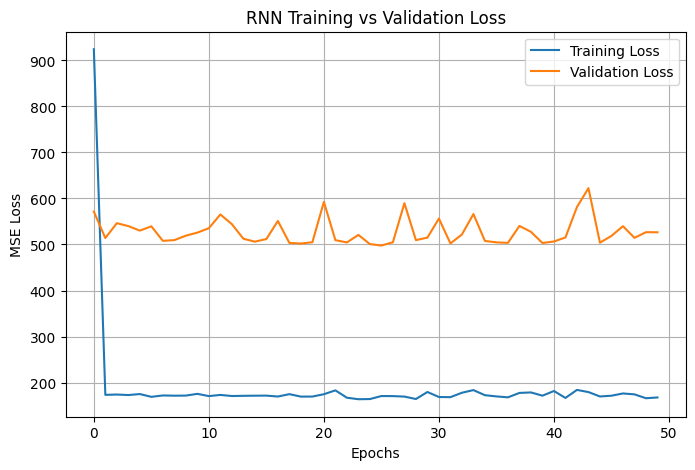

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.optimizers import Adam

# Assuming X_train, X_test, y_train, y_test are already defined from Q1.3
# Reshape input data for RNN: (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Build RNN model
model_rnn = Sequential([
    SimpleRNN(40, activation='relu', input_shape=(X_train.shape[1], 1)),
    Dense(1)  # Output layer for next-day prediction
])

# Compile the model
model_rnn.compile(optimizer=Adam(), loss='mse')

# Train the model
history_rnn = model_rnn.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

# Plot training vs validation loss
plt.figure(figsize=(8,5))
plt.plot(history_rnn.history['loss'], label='Training Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')
plt.title('RNN Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Root Mean Squared Error (RMSE): 22.9468
Mean Absolute Error (MAE): 18.3608


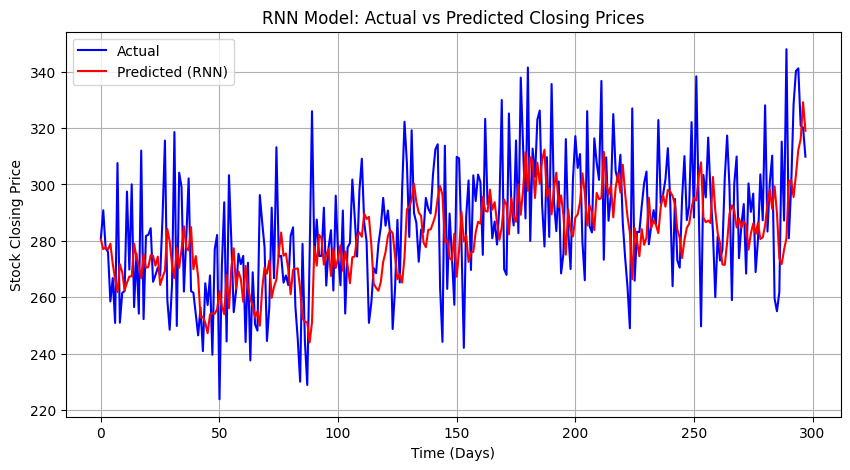

In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

# Make predictions using the trained RNN model
y_pred_rnn = model_rnn.predict(X_test)

# Calculate RMSE and MAE
rmse_rnn = np.sqrt(mean_squared_error(y_test, y_pred_rnn))
mae_rnn = mean_absolute_error(y_test, y_pred_rnn)

print("Root Mean Squared Error (RMSE):", round(rmse_rnn, 4))
print("Mean Absolute Error (MAE):", round(mae_rnn, 4))

# Plot Actual vs Predicted values
plt.figure(figsize=(10,5))
plt.plot(y_test, label='Actual', color='blue')
plt.plot(y_pred_rnn, label='Predicted (RNN)', color='red')
plt.title('RNN Model: Actual vs Predicted Closing Prices')
plt.xlabel('Time (Days)')
plt.ylabel('Stock Closing Price')
plt.legend()
plt.grid(True)
plt.show()


*Write your Answer to Q3.3 Here:*

We used a smaller batch size for the RNN because it works with sequences, and smaller batches help it learn patterns over time more accurately. RNNs often struggle with long-term dependencies since information from earlier time steps fades as new data is processed (vanishing gradient problem). In this case, the RNN performed better than the CNN, doing a good job capturing short-term movements and the general direction of prices. However, the error values show it still misses some long-term trends in the data.

### Question 4 - Long Short-Term Memory (LSTM) (20%)
- Q4.1 Create an LSTM model for time series forecasting.The model should include two LSTM layers of size 100 and 50, and ReLU activation. Train the model using the provided dataset for 100 epochs. Use the batch_size of 16, and ADAM optimizer. Plot the training loss and validation loss. (12%)
- Q4.2 Evaluate the model's performance using RMSE and MAE on the test set. Plot the predicted values alongside the actual values to visualize how well the model is forecasting the time series. (6%)
- Q4.3 Why do we use a larger epoch compared to RNN? (2%)

Epoch 1/100


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 4746.6143 - val_loss: 465.5778
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 197.8283 - val_loss: 463.9208
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 183.1943 - val_loss: 468.4233
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 170.1644 - val_loss: 669.5078
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 187.4050 - val_loss: 478.0163
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 174.8733 - val_loss: 471.1611
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 167.0602 - val_loss: 505.5681
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 180.1395 - val_loss: 470.3346
Epoch 9/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 172.7593 - val_loss: 484.2899
Epoch 10/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 170.5732 - val_loss: 473.5713
Epoch 11/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 202.2878 - val_loss: 474.2199
Epoch 12/100
75/75 ━━━━━━━━━━━

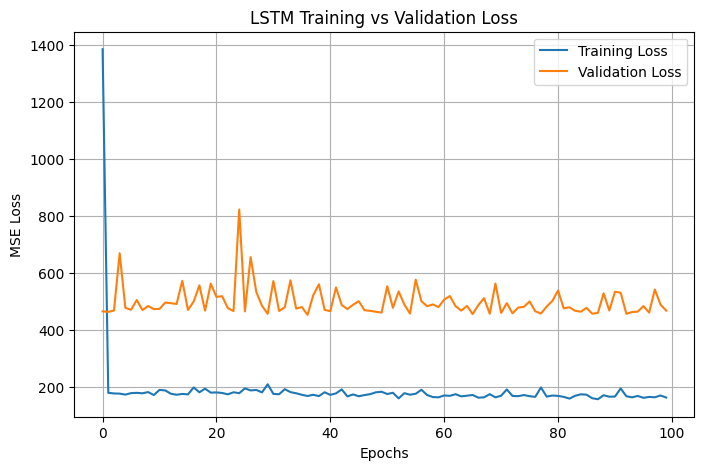

In [17]:
# Q4.1: LSTM Model for Time Series Forecasting
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Reshape X to 3D (samples, timesteps, features) if not done already
# Each window is a sequence of 10 timesteps with 1 feature
X_train_lstm = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_lstm = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Build LSTM model
lstm_model = Sequential([
    LSTM(100, activation='relu', return_sequences=True, input_shape=(X_train_lstm.shape[1], 1)),
    LSTM(50, activation='relu'),
    Dense(1)  # Output layer for next-day prediction
])

# Compile model
lstm_model.compile(optimizer=Adam(), loss='mse')

# Train the model
history_lstm = lstm_model.fit(
    X_train_lstm, y_train,
    epochs=100,
    batch_size=16,
    validation_data=(X_test_lstm, y_test),
    verbose=1
)

# Plot training vs validation loss
plt.figure(figsize=(8,5))
plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
LSTM Root Mean Squared Error (RMSE): 21.6433
LSTM Mean Absolute Error (MAE): 17.4577


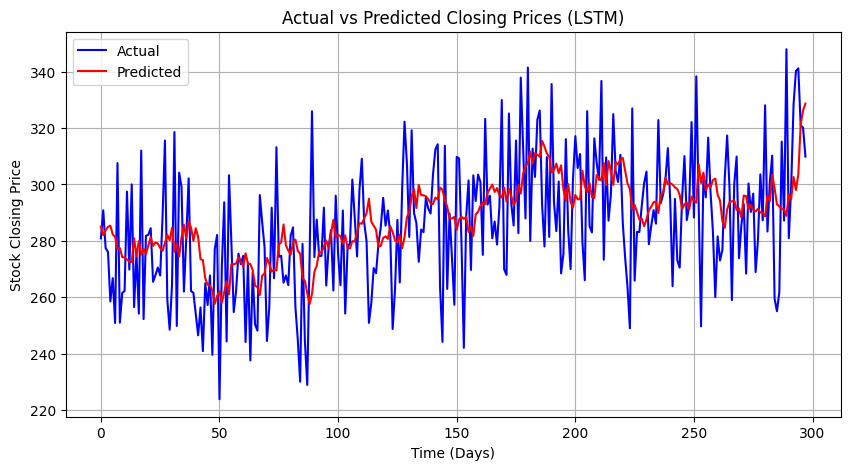

In [18]:
# Evaluate performance
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

y_pred_lstm = lstm_model.predict(X_test_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred_lstm))
mae_lstm = mean_absolute_error(y_test, y_pred_lstm)

print("LSTM Root Mean Squared Error (RMSE):", round(rmse_lstm, 4))
print("LSTM Mean Absolute Error (MAE):", round(mae_lstm, 4))

# Plot actual vs predicted
plt.figure(figsize=(10,5))
plt.plot(y_test, label='Actual', color='blue')
plt.plot(y_pred_lstm, label='Predicted', color='red')
plt.title('Actual vs Predicted Closing Prices (LSTM)')
plt.xlabel('Time (Days)')
plt.ylabel('Stock Closing Price')
plt.legend()
plt.grid(True)
plt.show()


*Write your Answer to Q4.3 Here:*

We use a larger number of epochs for the LSTM compared to a vanilla RNN because LSTMs have more parameters due to their memory cells and gates, which makes them more complex and slower to learn. Training for more epochs allows the LSTM to fully capture long-term dependencies in the time series and converge to a better solution, improving prediction accuracy.

### Question 5 - Gated Recurrent Unit (GRU) (20%)
- Q5.1 Create a GRU model for time series forecasting.The model should include two GRU layers of size 80 and 40, and ReLU activation. Train the model using the provided dataset for 100 epochs. Use the batch_size of 16, and ADAM optimizer. Plot the training loss and validation loss. (12%)
- Q5.2 Evaluate the model's performance using RMSE and MAE on the test set. Plot the predicted values alongside the actual values to visualize how well the model is forecasting the time series.(6%)
- Q5.3 How does the GRU compare to LSTM in terms of computational efficiency and forecasting performance? (2%)

Epoch 1/100


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 21089.3320 - val_loss: 473.0763
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 164.1969 - val_loss: 457.7528
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 153.2362 - val_loss: 459.0070
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 158.1354 - val_loss: 477.2473
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 175.0258 - val_loss: 468.6038
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 160.0114 - val_loss: 485.0995
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 172.0815 - val_loss: 457.2600
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 153.3904 - val_loss: 461.7288
Epoch 9/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 160.0435 - val_loss: 472.7740
Epoch 10/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 151.4245 - val_loss: 469.6283
Epoch 11/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 177.9281 - val_loss: 459.6157
Epoch 12/100
75/75 ━━━━━━━━━━

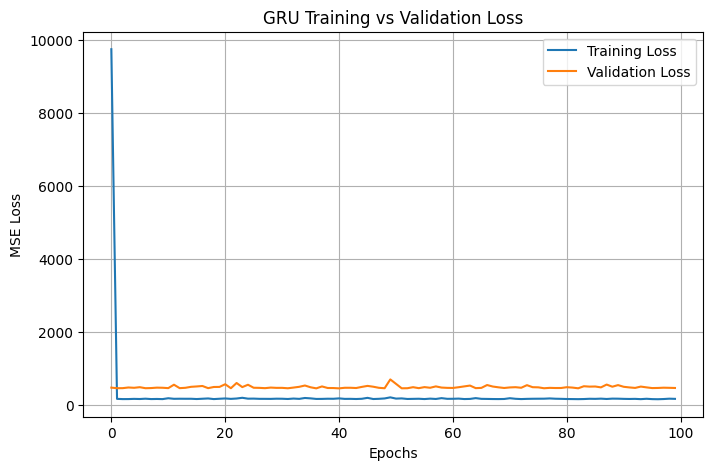

In [19]:
# Q5.1: GRU Model for Time Series Forecasting
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Reshape input to 3D (samples, timesteps, features)
X_train_gru = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_gru = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Build GRU model
gru_model = Sequential([
    GRU(80, activation='relu', return_sequences=True, input_shape=(X_train_gru.shape[1], 1)),
    GRU(40, activation='relu'),
    Dense(1)  # Output layer for next-day prediction
])

# Compile model
gru_model.compile(optimizer=Adam(), loss='mse')

# Train the model
history_gru = gru_model.fit(
    X_train_gru, y_train,
    epochs=100,
    batch_size=16,
    validation_data=(X_test_gru, y_test),
    verbose=1
)

# Plot training vs validation loss
plt.figure(figsize=(8,5))
plt.plot(history_gru.history['loss'], label='Training Loss')
plt.plot(history_gru.history['val_loss'], label='Validation Loss')
plt.title('GRU Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
GRU Root Mean Squared Error (RMSE): 21.5359
GRU Mean Absolute Error (MAE): 17.3925


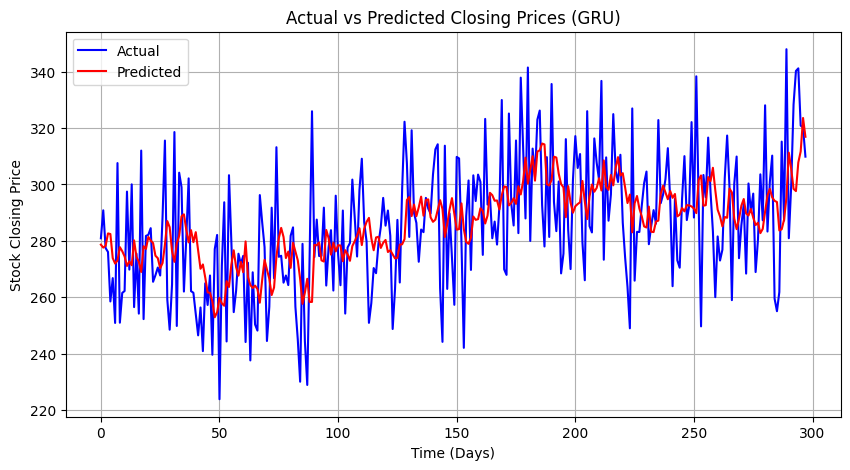

In [21]:
# Evaluate performance
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

y_pred_gru = gru_model.predict(X_test_gru)
rmse_gru = np.sqrt(mean_squared_error(y_test, y_pred_gru))
mae_gru = mean_absolute_error(y_test, y_pred_gru)

print("GRU Root Mean Squared Error (RMSE):", round(rmse_gru, 4))
print("GRU Mean Absolute Error (MAE):", round(mae_gru, 4))

# Plot actual vs predicted
plt.figure(figsize=(10,5))
plt.plot(y_test, label='Actual', color='blue')
plt.plot(y_pred_gru, label='Predicted', color='red')
plt.title('Actual vs Predicted Closing Prices (GRU)')
plt.xlabel('Time (Days)')
plt.ylabel('Stock Closing Price')
plt.legend()
plt.grid(True)
plt.show()

*Write your Answer to Q5.3 Here:*

The GRU slightly outperforms the LSTM in your results (RMSE: 21.5359 vs 21.6433, MAE: 17.3925 vs 17.4577), though the difference is minimal and visually the predictions look very similar.

In terms of computational efficiency, GRUs are simpler than LSTMs because they have fewer gates, which means they train faster and require less memory, while still capturing long-term dependencies effectively. This makes GRUs a good alternative when similar forecasting accuracy is achieved with lower computational cost.

### Question 6 - Discussion (5%)
- Q6.1 Compare the performance of 1D-CNN, RNN, LSTM, and GRU models based on training and test execution time, performance (RMSE and MAE), and potential overfitting/underfitting. (3%)
- Q6.2 Discuss in which cases you would prefer using 1D-CNN vs LSTM or GRU for time series data. (2%)


**Write your Answer to Q6.1 Here:**

The 1D-CNN achieved the highest RMSE (25.68) and MAE (20.50), indicating the lowest accuracy but the fastest training and testing times. It slightly underfits since it captures only short-term temporal patterns.

The RNN improved performance (RMSE 22.95, MAE 18.36) but trained slower and can struggle with long-term dependencies.
LSTM (RMSE 21.64, MAE 17.46) and GRU (RMSE 21.54, MAE 17.39) achieved the best accuracy, effectively modeling long-term relationships. GRU performed nearly as well as LSTM but trained faster due to fewer parameters.

Overall, accuracy ranking: GRU ≈ LSTM > RNN > 1D-CNN,
Speed ranking: 1D-CNN < RNN < GRU < LSTM.
CNN shows mild underfitting, while LSTM/GRU risk slight overfitting but yield superior results.

**Write your Answer to Q6.2 Here:**

Use 1D-CNN for large datasets, fast computation, or when capturing short-term patterns is sufficient.
Use LSTM or GRU when modeling long-term temporal dependencies or complex sequential relationships.
Between the two, GRU is preferred for similar accuracy with faster training and lower complexity.

In short, 1D-CNN suits efficiency and short-term analysis, while LSTM/GRU excel in accuracy and long-term forecasting.